<a href="https://colab.research.google.com/github/Meexargha/AI-LAB-CODE-IIIT-G/blob/main/DAY_2_assignment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

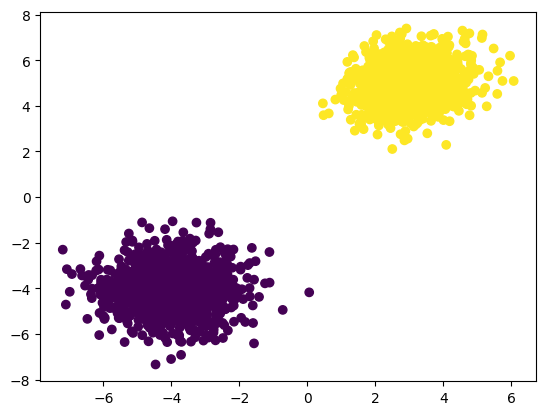

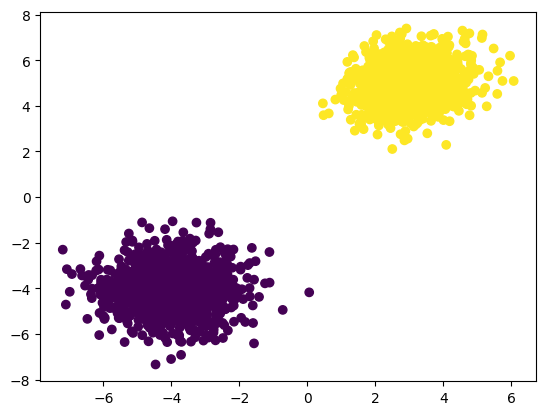

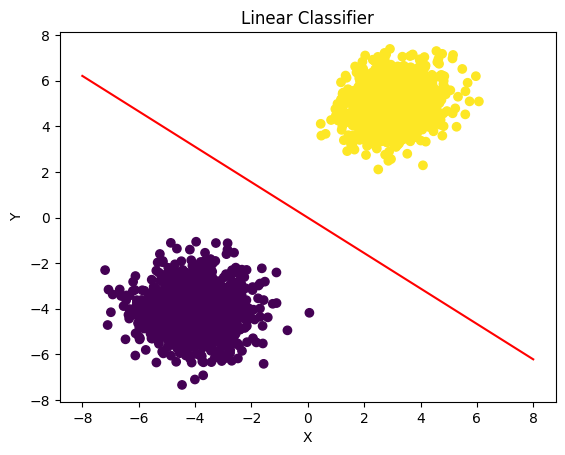

In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# number of samples

num_samples_per_class = 1000

# two class - 1st class
negative_samples = tf.convert_to_tensor(
    np.random.multivariate_normal(
        mean=[-4,-4],
        cov=[[1,0],
              [0,1]],
        size=num_samples_per_class
    ),
    dtype=tf.float32
)

# 2nd class
positive_samples = tf.convert_to_tensor(
    np.random.multivariate_normal(
        mean=[3,5],
        cov=[[0.81,0.2],
              [0.2,0.81]],
        size=num_samples_per_class
    ),
    dtype=tf.float32
)
#concat the two classes
inputs = tf.concat(
    [negative_samples,positive_samples],
    axis=0
)

# That part labels/differentiates the two classes:
#Negative samples → 0
#Positive samples → 1

target = tf.concat(
    [
        tf.zeros((num_samples_per_class,1)),
        tf.ones((num_samples_per_class,1))
    ],
    axis=0
)
# plot the data  c=targets[:, 0] use 2d and :->takes all the rows and 0->takes all the colmn
plt.scatter(
    # takes the value of x->0
    inputs[:, 0],
    #takes the value of y ->1
    inputs[:, 1],
    c=target[:,0]
)
plt.show()

# create W and b

input_dim = 2
output_dim = 1

#W controls how much each input contributes to the final output
W = tf.Variable(
    #tf.random.uniform is creating random number
    initial_value=tf.random.uniform(
        shape=(input_dim, output_dim)
    )
)
# b is the single sclaer cofficeint
b = tf.Variable(
    initial_value=tf.zeros(
        shape=(output_dim,)
    )
)

# model->does the matrix mul with input and w

def model(inputs, W, b):
   return tf.matmul(inputs, W) + b

   # loss function

def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(
        targets - predictions
    )
    return tf.reduce_mean(
        per_sample_losses
    )


    # training step

learning_rate = 0.1

def training_step(inputs, targets, W, b):

    with tf.GradientTape() as tape:

        predictions = model(inputs, W, b)

        loss = mean_squared_error(
            targets,
            predictions
        )

    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(
        loss,
        [W, b]
    )

    W.assign_sub(
        grad_loss_wrt_W * learning_rate
    )

    b.assign_sub(
        grad_loss_wrt_b * learning_rate
    )

    return loss

    # batch training

for step in range(40):

    loss = training_step(
        inputs,
        target,
        W,
        b
    )
    # predictions

predictions = model(
    inputs,
    W,
    b
)
plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c=predictions[:, 0] > 0.5
)

plt.show()
# plot the classifier

x = np.linspace(-8, 8, 100)

y = (
    -W[0, 0].numpy() / W[1, 0].numpy() * x
    + (0.5 - b[0].numpy()) / W[1, 0].numpy()
)

plt.plot(x, y, "r")

plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c=predictions[:, 0] > 0.5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Classifier")

plt.show()